In [ ]:
import mysql.connector
import pandas as pd

# Establish the connection
try:
    db_connection = mysql.connector.connect(
        host="localhost",
        user="USERNAME",
        password="PASSWORD", 
        database="banking_project"
    )
    print("Successfully connected to the database!")

    # Fetch the data using a SQL query
    query = "SELECT * FROM churn_data"
    df = pd.read_sql(query, con=db_connection)
    
    # Show the first few rows
    print("Data loaded successfully! Here are the first 5 rows:")
    display(df.head())

except Exception as e:
    print(f"Error: {e}")

finally:
    if 'db_connection' in locals() and db_connection.is_connected():
        db_connection.close()
        print("MySQL connection is closed.")

Successfully connected to the database!


C:\Users\USER\AppData\Local\Temp\ipykernel_15652\3971957452.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=db_connection)


Data loaded successfully! Here are the first 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,b'1',b'1',101348.88,b'1'
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,b'0',b'1',112542.58,b'0'
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,b'1',b'0',113931.57,b'1'
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,b'0',b'0',93826.63,b'0'
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,b'1',b'1',79084.10,b'0'


MySQL connection is closed.


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  object 
 11  IsActiveMember   10000 non-null  object 
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  object 
dtypes: float64(2), int64(6), object(6)
memory usage: 1.1+ MB
None

--- Summary Statistics ---


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,100090.239881
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,57510.492818
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,51002.110000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,100193.915000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,149388.247500
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000


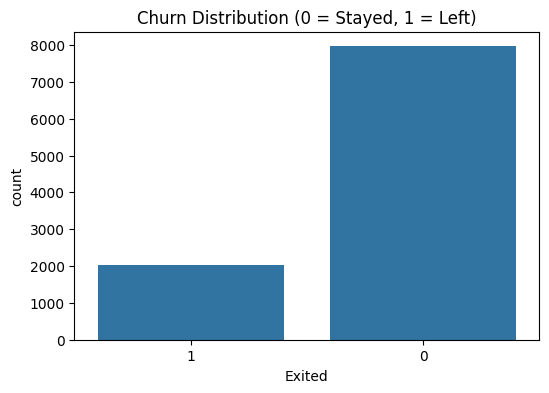

In [2]:
# Check for missing values and data types
print("--- Dataset Info ---")
print(df.info())

# Get statistical summary (Mean, Median, etc.)
print("\n--- Summary Statistics ---")
display(df.describe())

# Check the ratio of people who stayed (0) vs. people who left (1)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df)
plt.title('Churn Distribution (0 = Stayed, 1 = Left)')
plt.show()

In [3]:
# Drop columns that are just identifiers and don't contribute to behavior
df_cleaned = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

print("Columns before cleaning:", df.shape[1])
print("Columns after cleaning:", df_cleaned.shape[1])
display(df_cleaned.head())

Columns before cleaning: 14
Columns after cleaning: 11


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,b'1',b'1',101348.88,b'1'
1,608,Spain,Female,41,1,83807.86,1,b'0',b'1',112542.58,b'0'
2,502,France,Female,42,8,159660.80,3,b'1',b'0',113931.57,b'1'
3,699,France,Female,39,1,0.00,2,b'0',b'0',93826.63,b'0'
4,850,Spain,Female,43,2,125510.82,1,b'1',b'1',79084.10,b'0'


C:\Users\USER\AppData\Local\Temp\ipykernel_15652\4010926760.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Age', data=df_cleaned, ax=ax[0], palette="Set2")
C:\Users\USER\AppData\Local\Temp\ipykernel_15652\4010926760.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Exited', y='Balance', data=df_cleaned, ax=ax[1], palette="Set1")


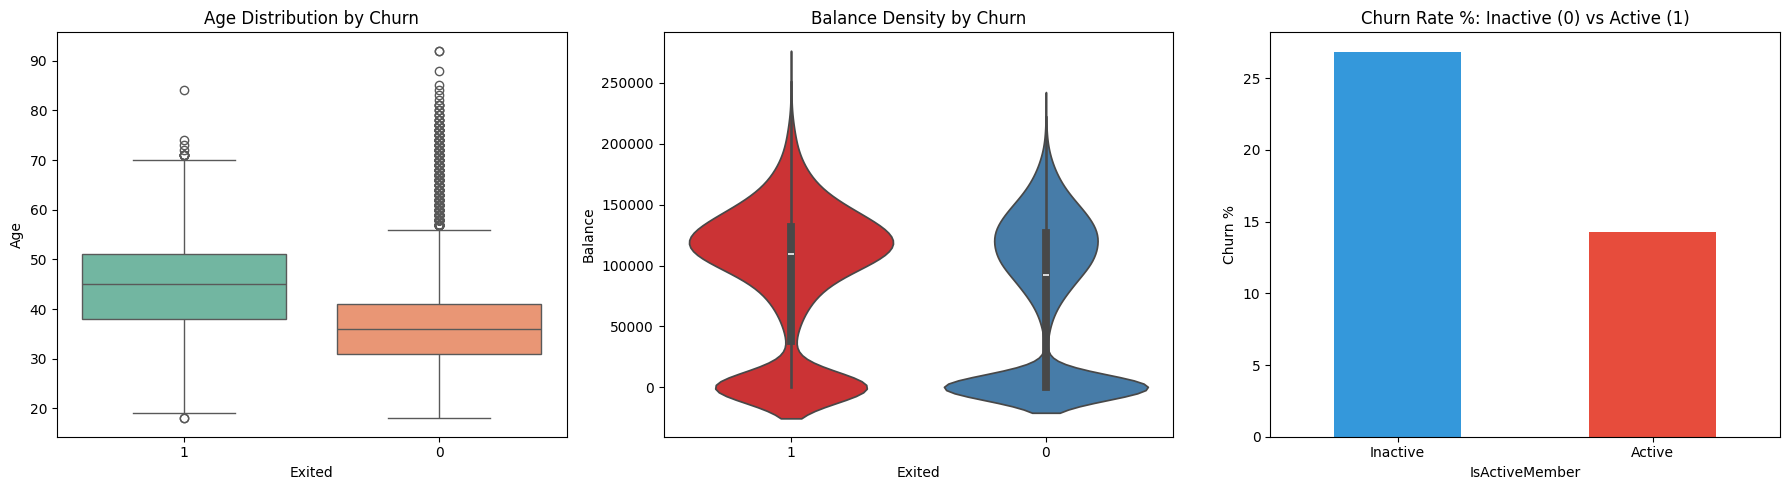

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a layout for 3 charts
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# 1. Age vs Churn (Boxplot)
sns.boxplot(x='Exited', y='Age', data=df_cleaned, ax=ax[0], palette="Set2")
ax[0].set_title('Age Distribution by Churn')

# 2. Balance vs Churn (Violin Plot - shows density)
sns.violinplot(x='Exited', y='Balance', data=df_cleaned, ax=ax[1], palette="Set1")
ax[1].set_title('Balance Density by Churn')

# 3. Active Status vs Churn (Percentage Bar Chart)
#active_churn = df_cleaned.groupby('IsActiveMember')['Exited'].mean() * 100
#active_churn.plot(kind='bar', ax=ax[2], color=['#3498db', '#e74c3c'])
#ax[2].set_title('Churn Rate %: Inactive (0) vs Active (1)')
#ax[2].set_ylabel('Churn %')

# 1. Ensure 'Exited' is an integer so we can calculate the mean
df_cleaned['Exited'] = df_cleaned['Exited'].astype(int)

# 2. Re-run the grouping (numeric_only=True ensures it finds the column)
active_churn = df_cleaned.groupby('IsActiveMember')['Exited'].mean() * 100

# 3. Plot again
active_churn.plot(kind='bar', ax=ax[2], color=['#3498db', '#e74c3c'])
ax[2].set_title('Churn Rate %: Inactive (0) vs Active (1)')
ax[2].set_ylabel('Churn %')
ax[2].set_xticklabels(['Inactive', 'Active'], rotation=0) # Make labels readable

plt.tight_layout()
plt.show()

In [5]:
# 1. Convert Gender to binary (0/1)
df_cleaned['Gender'] = df_cleaned['Gender'].map({'Female': 1, 'Male': 0})

# 2. Convert Geography into separate columns (France is the baseline)
df_final = pd.get_dummies(df_cleaned, columns=['Geography'], drop_first=True)

# 3. View your "AI-Ready" data
print("Data shape for AI:", df_final.shape)
display(df_final.head())

Data shape for AI: (10000, 12)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,1,42,2,0.00,1,b'1',b'1',101348.88,1,False,False
1,608,1,41,1,83807.86,1,b'0',b'1',112542.58,0,False,True
2,502,1,42,8,159660.80,3,b'1',b'0',113931.57,1,False,False
3,699,1,39,1,0.00,2,b'0',b'0',93826.63,0,False,False
4,850,1,43,2,125510.82,1,b'1',b'1',79084.10,0,False,True


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Define Features (X) and Target (y)
X = df_final.drop('Exited', axis=1)
y = df_final['Exited']

# Split: 80% to learn from, 20% to test its 'intelligence'
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make Predictions
predictions = model.predict(X_test)

print("--- Model Performance ---")
print(classification_report(y_test, predictions))

--- Model Performance ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [7]:
# 1. Balance to Salary Ratio: Shows if a customer is "bank-dependent"
df_final['Balance_Salary_Ratio'] = df_final['Balance'] / (df_final['EstimatedSalary'] + 1)

# 2. Tenure by Age: Shows loyalty relative to life stage
df_final['Tenure_Age_Ratio'] = df_final['Tenure'] / (df_final['Age'] + 1)

# 3. Credit Score by Age: Identifies "Financial Maturity"
df_final['CreditScore_Age_Ratio'] = df_final['CreditScore'] / (df_final['Age'] + 1)

# Let's see the new columns
display(df_final[['Balance_Salary_Ratio', 'Tenure_Age_Ratio', 'CreditScore_Age_Ratio']].head())

,Balance_Salary_Ratio,Tenure_Age_Ratio,CreditScore_Age_Ratio
0,0.000000,0.046512,14.395349
1,0.744670,0.023810,14.476190
2,1.401362,0.186047,11.674419
3,0.000000,0.025000,17.475000
4,1.587035,0.045455,19.318182


In [8]:
# 1. Define the Target (y)
# This is what we want the AI to predict
y = df_final['Exited']

# 2. Define the Features (X)
# We take the entire final dataframe and DROP the 'Exited' column
X = df_final.drop('Exited', axis=1)

# 3. Double check the columns to ensure your new ratios are there
print("Features being sent to AI:")
print(X.columns.tolist())

# 4. Show the shape (Rows, Columns)
print(f"\nTotal samples: {X.shape[0]}")
print(f"Total features: {X.shape[1]}")

Features being sent to AI:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Balance_Salary_Ratio', 'Tenure_Age_Ratio', 'CreditScore_Age_Ratio']

Total samples: 10000
Total features: 14


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Split with 'stratify' to handle the 80/20 imbalance correctly
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train
model_improved = RandomForestClassifier(n_estimators=100, random_state=42)
model_improved.fit(X_train, y_train)

# Final Results
print("--- Improved Model Results ---")
print(classification_report(y_test, model_improved.predict(X_test)))

--- Improved Model Results ---
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



C:\Users\USER\AppData\Local\Temp\ipykernel_15652\930555663.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


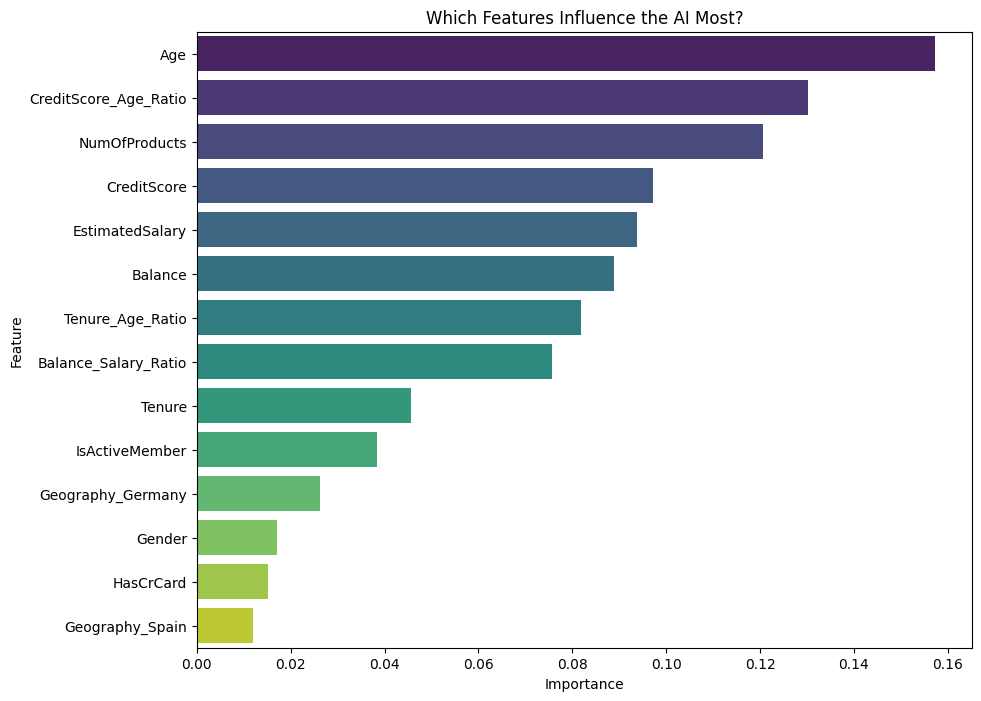

In [10]:
importances = model_improved.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Which Features Influence the AI Most?')
plt.show()